In [17]:
import pandas as pd
import numpy as np
import textstat
import string
import spacy
import re

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
nltk.download('cmudict')

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\redga\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


In [2]:
golden_phrases = pd.read_csv("../data/golden_phrases/golden_phrases_TweetEmotionsPTBR.csv")

In [8]:
textstat.set_lang("pt")

## (1) Functions and Processing

In [9]:
nlp = spacy.load("pt_core_news_lg", disable=["ner"])

AUXILIARY_VERBS_PT = {
    "ser", "estar", "ter", "haver", "ir"
}

def get_textstat_features(texts):
    features = []
    for x in texts:
        n_sent = max(textstat.sentence_count(x), 1)
        n_words = max(textstat.lexicon_count(x), 1)

        features.append([
            textstat.letter_count(x),
            n_sent,
            textstat.avg_letter_per_word(x),
            n_words / n_sent,
            textstat.avg_syllables_per_word(x),
            textstat.reading_time(x),
            textstat.fernandez_huerta(x),
            textstat.szigriszt_pazos(x),
            textstat.gutierrez_polini(x)
        ])
    return np.array(features)

def mean_punctuation_per_word(texts):
    punct = set(string.punctuation)
    results = []

    for txt in texts:
        words = txt.split()
        n_words = len(words)

        if n_words == 0:
            results.append([0.0, 0.0, 0.0])
            continue

        total_punct = sum(1 for ch in txt if ch in punct)
        exclam = txt.count("!")
        quest = txt.count("?")
        
        results.append([
            total_punct / n_words,
            exclam / n_words,
            quest / n_words
        ])
    return np.array(results)

def mean_verbs_per_word(texts):
    feats = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "lemmatizer", "parser"]):
        words = [t for t in doc if t.is_alpha]
        if len(words) == 0:
            feats.append(0.0)
            continue
        verb_count = sum(1 for t in words if t.pos_ == "VERB")
        feats.append(verb_count / len(words))
    return np.array(feats).reshape(-1, 1)

def mean_auxiliaries_per_word(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "parser"]):
        tokens = [tok for tok in doc if tok.is_alpha]
        if len(tokens) == 0:
            results.append(0.0)
            continue

        aux_count = sum(1 for tok in tokens if tok.lemma_.lower() in AUXILIARY_VERBS_PT)
        results.append(aux_count / len(tokens))
    return results

def mean_auxiliaries_per_sentence(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner"]):
        n_sent = len(list(doc.sents))
        if n_sent == 0:
            results.append(0.0)
            continue

        tokens = [tok for tok in doc if tok.is_alpha]

        aux_count = sum(
            1 for tok in tokens
            if tok.lemma_.lower() in AUXILIARY_VERBS_PT
        )

        results.append(aux_count / n_sent)
    return np.array(results)

def flesch_portuguese(texts):
    scores = []
    for t in texts:
        text = str(t).strip()

        num_sent = textstat.sentence_count(text)
        num_words = len(text.split())
        num_syll = textstat.syllable_count(text)

        if num_sent == 0 or num_words == 0:
            scores.append(0.0)
            continue

        flesch_pt = 226 - 1.04 * (num_words / num_sent) - 72 * (num_syll / num_words)
        scores.append(flesch_pt)

    return scores

def uppercase_percentage(texts):
    results = []

    for txt in texts:
        letters = [ch for ch in txt if ch.isalpha()]
        if len(letters) == 0:
            results.append(0.0)
            continue

        upper = sum(1 for ch in letters if ch.isupper())
        results.append(upper / len(letters))

    return np.array(results).reshape(-1, 1)

def mean_unique_word_length(texts):
    results = []

    for txt in texts:
        words = [w.lower() for w in txt.split() if w.isalpha()]
        unique_words = set(words)

        if len(unique_words) == 0:
            results.append(0.0)
            continue

        mean_len = np.mean([len(w) for w in unique_words])
        results.append(mean_len)

    return np.array(results).reshape(-1, 1)

def mean_char_repetition_per_word(texts):
    results = []
    pattern = re.compile(r"(.)\1{2,}")  # 3+ repetições

    for txt in texts:
        words = txt.split()
        if len(words) == 0:
            results.append(0.0)
            continue

        repeated_words = sum(
            1 for w in words if pattern.search(w.lower())
        )

        results.append(repeated_words / len(words))

    return np.array(results).reshape(-1, 1)

In [10]:
def emotion_similarity_features(texts, golden_df, emotion_col="EMOTIONS", phrase_cols=("GOLDEN_PHRASES_GPT", "GOLDEN_PHRASES_CLAUDE"), sep=";", 
                                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
    """
    Return a matrix (n_texts, n_emotions)
    """

    model = SentenceTransformer(model_name)

    emotion_phrases = {}
    
    for _, row in golden_df.iterrows():
        emotion = row[emotion_col]
        phrases = []

        for col in phrase_cols:
            phrases.extend(
                [p.strip() for p in row[col].split(sep) if p.strip()]
            )

        emotion_phrases[emotion] = phrases

    emotions = list(emotion_phrases.keys())

    text_embs = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)

    emotion_embs = {
        emo: model.encode(phrases, normalize_embeddings=True)
        for emo, phrases in emotion_phrases.items()
    }

    features = np.zeros((len(texts), len(emotions)))

    for j, emo in enumerate(emotions):
        sims = cosine_similarity(text_embs, emotion_embs[emo])
        features[:, j] = sims.mean(axis=1)

    return features, emotions

## (2) Features for TweetEmotionsPTBR

In [11]:
df = pd.read_csv("../data/treated/tweet_emotions_ptbr_treated.csv")

df['UNCLEAN_TEXT'] = (
    df['UNCLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...


In [12]:
unclean_text_col = 'UNCLEAN_TEXT'

textstat_feats = get_textstat_features(df[unclean_text_col].tolist()) 

textstat_cols = [
    "letter_count",
    "sentence_count",
    "avg_letter_per_word",
    "words_per_sentence",
    "avg_syllables_per_word",
    "reading_time",
    "fernandez_huerta",
    "szigriszt_pazos",
    "gutierrez_polini"
]

df_textstat = pd.DataFrame(textstat_feats, columns=textstat_cols) 
df = pd.concat([df.reset_index(drop=True), df_textstat.reset_index(drop=True)], axis=1)

punct_feats = mean_punctuation_per_word(df[unclean_text_col].tolist())

punct_cols = [
    "punctuation_per_word",
    "exclamation_per_word",
    "question_per_word"
]

df_punct = pd.DataFrame(punct_feats, columns=punct_cols)

df = pd.concat([df.reset_index(drop=True), df_punct], axis=1)

df["mean_verbs_per_word"] = mean_verbs_per_word(df[unclean_text_col])

df["mean_auxiliaries_per_word"] = mean_auxiliaries_per_word(df[unclean_text_col].tolist())
df["mean_auxiliaries_per_sentence"] = mean_auxiliaries_per_sentence(df[unclean_text_col].tolist())

df["flesch_portuguese"] = flesch_portuguese(df[unclean_text_col].tolist())

df["uppercase_percentage"] = uppercase_percentage(df[unclean_text_col].tolist())
df["mean_unique_word_length"] = mean_unique_word_length(df[unclean_text_col].tolist())
df["mean_char_repetition_per_word"] = mean_char_repetition_per_word(df[unclean_text_col].tolist())

emotion_feats, emotion_cols = emotion_similarity_features(
    texts=df[unclean_text_col].tolist(),
    golden_df=golden_phrases
)

emotion_feature_names = [f"sim_emotion_{emo}" for emo in emotion_cols]

df_emotion = pd.DataFrame(
    emotion_feats,
    columns=emotion_feature_names
)

df = pd.concat(
    [df.reset_index(drop=True), df_emotion.reset_index(drop=True)],
    axis=1
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\redga\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/389 [00:00<?, ?it/s]

In [13]:
base_cols = ["UNCLEAN_TEXT", "EMOTION", "CLEAN_TEXT"]

feature_cols = [c for c in df.columns if c not in base_cols]

df_final = df[base_cols + feature_cols]

df_final.to_csv(
    "../data/feat/tweet_emotions_ptbr_with_features.csv",
    index=False
)

In [14]:
print(df_final.shape)
print(df_final.isna().sum().sort_values(ascending=False).head(10))

(12419, 38)
UNCLEAN_TEXT              0
EMOTION                   0
CLEAN_TEXT                0
letter_count              0
sentence_count            0
avg_letter_per_word       0
words_per_sentence        0
avg_syllables_per_word    0
reading_time              0
fernandez_huerta          0
dtype: int64


In [15]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
letter_count,12419.0,93.207021,64.808588,4.000000,40.000000,73.000000,138.000000,253.000000
sentence_count,12419.0,1.480796,0.903465,1.000000,1.000000,1.000000,2.000000,8.000000
avg_letter_per_word,12419.0,4.605407,0.989092,1.666667,4.066667,4.460000,4.960000,37.000000
words_per_sentence,12419.0,14.964744,10.498853,1.000000,8.000000,12.000000,19.000000,60.000000
avg_syllables_per_word,12419.0,1.869633,0.393847,1.000000,1.666667,1.818182,2.000000,16.000000
reading_time,12419.0,1.408595,0.984560,0.058760,0.602290,1.101750,2.085980,3.745950
fernandez_huerta,12419.0,79.397986,24.517014,-754.180000,67.760000,81.131429,93.020000,145.820000
szigriszt_pazos,12419.0,75.392125,25.277836,-790.965000,63.635921,77.225909,89.597500,143.535000
gutierrez_polini,12419.0,45.289893,9.571998,-264.050000,41.180435,46.152083,50.631944,77.983333
punctuation_per_word,12419.0,0.121554,0.171617,0.000000,0.000000,0.088235,0.166667,4.000000


In [16]:
df_final.columns

Index(['UNCLEAN_TEXT', 'EMOTION', 'CLEAN_TEXT', 'letter_count',
       'sentence_count', 'avg_letter_per_word', 'words_per_sentence',
       'avg_syllables_per_word', 'reading_time', 'fernandez_huerta',
       'szigriszt_pazos', 'gutierrez_polini', 'punctuation_per_word',
       'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
       'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence',
       'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length',
       'mean_char_repetition_per_word', 'sim_emotion_tristeza',
       'sim_emotion_otimismo', 'sim_emotion_desprezo', 'sim_emotion_alegria',
       'sim_emotion_raiva', 'sim_emotion_agressividade',
       'sim_emotion_submissão', 'sim_emotion_nojo', 'sim_emotion_medo',
       'sim_emotion_decepção', 'sim_emotion_amor', 'sim_emotion_remorso',
       'sim_emotion_confianca', 'sim_emotion_antecipacao',
       'sim_emotion_surpresa', 'sim_emotion_intimidação'],
      dtype='object')

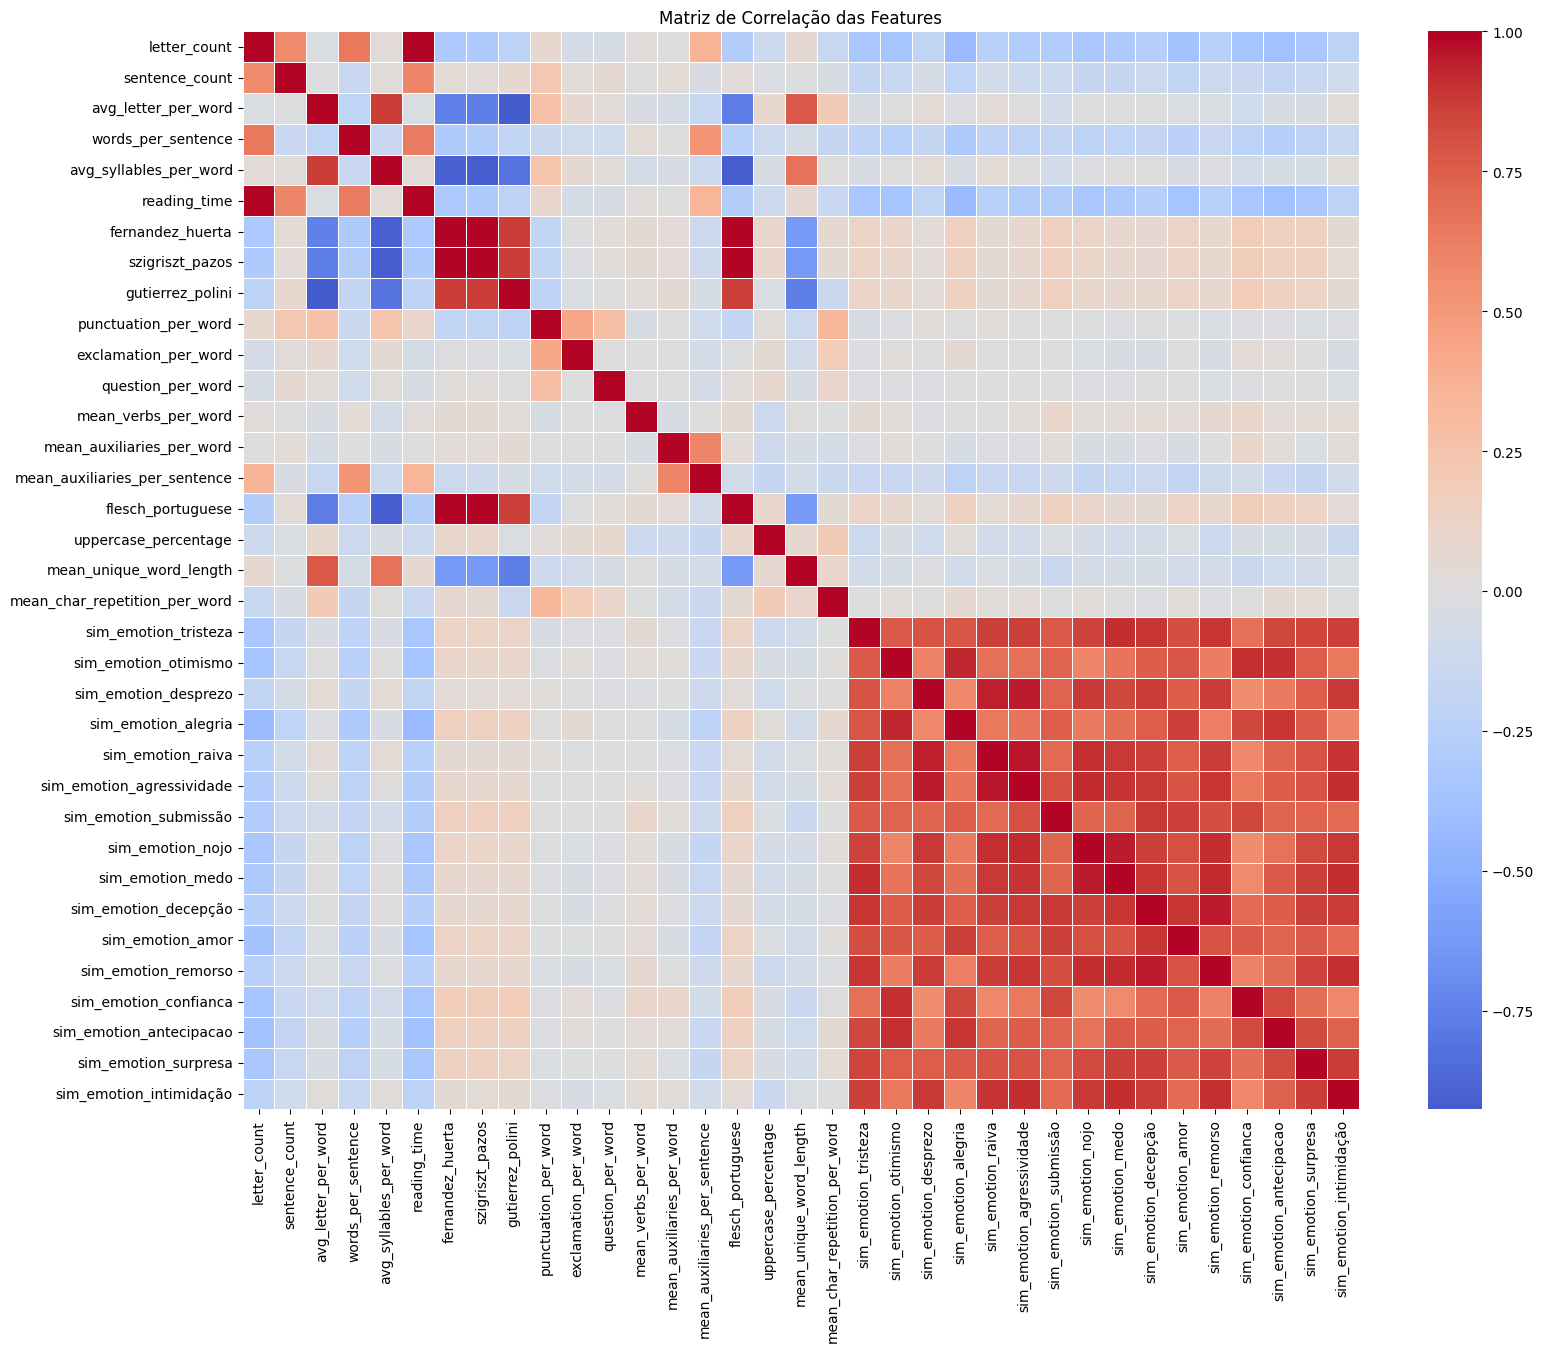

In [18]:
num_cols = df.select_dtypes(include="number")

corr = num_cols.corr(method="pearson")

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de Correlação das Features")
plt.show()